# Problem 2: Tourism Accommodation Statistics of Kärnten


## 1. Import the Main Data

Load the primary dataset `tourism.csv` and the auxiliary mapping `origin_category.csv`.

**Goal:** Understand the structure before analysis.

---
 It contains the following columns:

Tourismusjahr, dtype: int64 Year of the observation

Unterkunft, dtype: object Type of accommodation. Includes hotels of different comfort levels, vacation homes, campign sites, et cetera.

Herkunft, dtype: object Origin of the travellers. Split into states in Austria, Germany, countries in Europe and elsewhere in the world. Some countries are aggregated (e.g. "Übriges Asien").

---


The file origin_category.csv contains a categorization of all origin values into four groups: Austria, Germany, Europe, International (as in "rest of the world"). This categorization may be useful for presenting the data.

 Ankünfte, dtype: int64 Amount of arrivals in given year, in given type of accommodation, by travellers of given origin.

 Übernachtungen, dtype: int64 Amount of nights spent in given year, in given type of accommodation, by travellers of given origin.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sns

df_tourism= pd.read_csv('data_tourism/tourism.csv')
df_origin_category =pd.read_csv('data_tourism/origin_category.csv')
df_tourism

,Tourismusjahr,Unterkunft,Herkunft,Ankünfte,Übernachtungen
0,2008,Bewirtschaftete Schutzhütten,Australien,2,2
1,2008,Bewirtschaftete Schutzhütten,Baden Württemberg,440,632
2,2008,Bewirtschaftete Schutzhütten,Bayern,836,1608
3,2008,Bewirtschaftete Schutzhütten,Belgien,78,110
4,2008,Bewirtschaftete Schutzhütten,Berlin,570,657
...,...,...,...,...,...
11989,2021,Unterkunft auf Bauernhof,ehem. Jugoslawien,130,1287
11990,2021,Unterkunft auf Bauernhof,Übriges Afrika,14,60
11991,2021,Unterkunft auf Bauernhof,Übriges Asien,15,32
11992,2021,Unterkunft auf Bauernhof,Übriges Ausland,23,256


## 2. Total Nights by Tourist Origin

Visualize the total number of nights spent by tourists from different origins. The auxiliary
file origin_category.csv may be useful here. (1-2 charts)

**Hint:** Use `origin_category.csv` to group origins into meaningful categories (e.g., Domestic, Germany, Europe, Other International).

**Deliverables:**
- Bar chart: Total nights per origin category.
- Optional: Pie chart for proportional comparison.

**Critical thinking:**
- Which origin group dominates?
- Do the results match expectations for a border region like Kärnten?

---

# Put the legend of pie chart outside

In [2]:
#add the origin category to the main dataset
origin_col = []
for country in df_tourism['Herkunft']:
    origin = df_origin_category[df_origin_category['Herkunft'] == country]['Herkunft Kategorie'].tolist()[0]
    origin_col.append(origin)

df_tourism.insert(len(df_tourism.columns)-1, 'Herkunft Kategorie', origin_col)


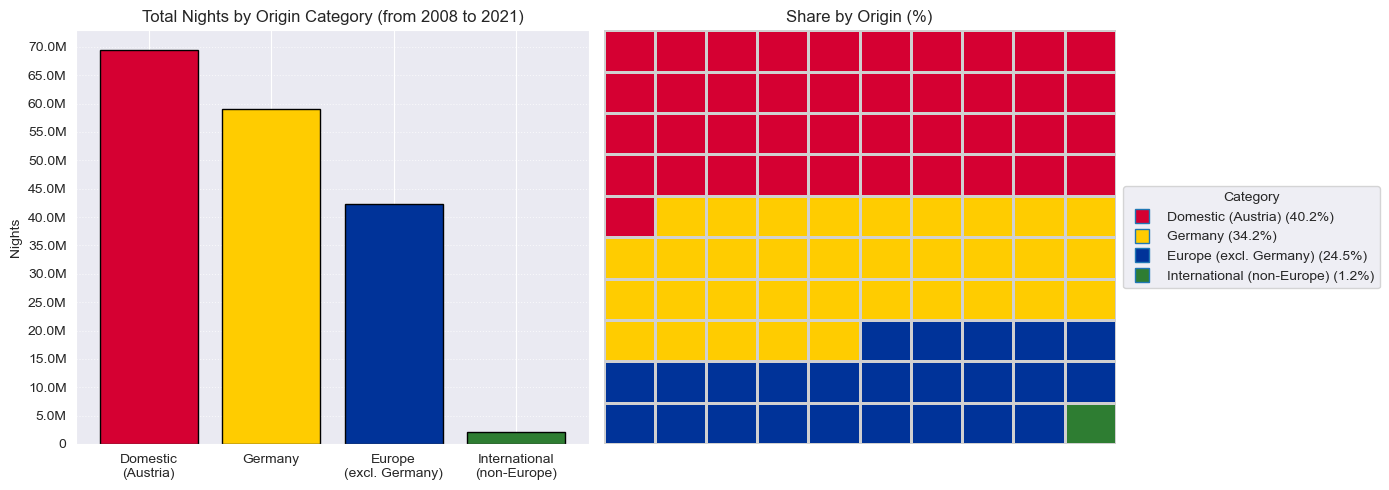

In [3]:
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from matplotlib.colors import ListedColormap

group_a = df_tourism.groupby('Herkunft Kategorie').agg({'Übernachtungen':'sum'})
color_map = {
    "Germany": "#FFCC00",
    "Domestic (Austria)": "#D50032",
    "Europe (excl. Germany)": "#003399",
    "International (non-Europe)": "#2E7D32",
}

cat_map = {
    "AT": "Domestic (Austria)",
    "DE": "Germany",
    "EUR": "Europe (excl. Germany)",
    "INT": "International (non-Europe)"
}
group_a = group_a.rename(index=cat_map)

def human_format(x, pos):
    if x >= 1e6: return f'{x/1e6:.1f}M'
    if x >= 1e3: return f'{x/1e3:.0f}k'
    return f'{x:.0f}'

fig, axs = plt.subplots(1, 2, figsize=(14,5))

axs[0].cla()
axs[0].bar(group_a.index, group_a['Übernachtungen'],
           color=[color_map[l] for l in group_a.index],
           edgecolor='black')
axs[0].set_title("Total Nights by Origin Category (from 2008 to 2021)")
axs[0].set_ylabel("Nights")
axs[0].set_xticks(range(len(group_a)))

axs[0].set_xticklabels([
    'Domestic\n(Austria)',
    'Germany',
    'Europe\n(excl. Germany)',
    'International\n(non-Europe)'
])
axs[0].set_yticks(range(0,int(71* 1e6), int(5*1e6) ))

axs[0].yaxis.set_major_formatter(FuncFormatter(human_format))
axs[0].grid(axis='y', linestyle=':', alpha=0.7)
axs[0].tick_params(axis='x', rotation=0)



# --- WAFFLE ---
sizes = group_a['Übernachtungen'].values
labels = list(group_a.index)
perc = sizes / sizes.sum()

n_rows = n_cols = 10; total = n_rows * n_cols
n = np.round(perc * total).astype(int)
while n.sum() < total: n[np.argmax(perc)] += 1
while n.sum() > total: n[np.argmax(n)] -= 1

flat = np.concatenate([np.full(k, i) for i, k in enumerate(n)])
grid = flat.reshape(n_rows, n_cols)
grid = grid[::-1]

cmap = ListedColormap(['#a6a6a6', '#1f77b4', '#2ca02c', '#ff7f0e'][:len(labels)])

X, Y = np.meshgrid(np.arange(n_cols+1), np.arange(n_rows+1))

palette = [color_map[l] for l in labels]
cmap = ListedColormap(palette)

axs[1].pcolormesh(X, Y, grid, cmap=cmap, shading='flat',
                  edgecolors='#D0D0D0', linewidth=1)   # l
axs[1].axis('off')
axs[1].set_xlim(0, n_cols)
axs[1].set_ylim(0, n_rows)
axs[1].axis('off')
axs[1].set_title("Share by Origin (%)")

legend_labels = [f"{name} ({p*100:.1f}%)" for name, p in zip(labels, perc)]
handles = [plt.Line2D([0],[0], marker='s', linestyle='', markersize=10, markerfacecolor=cmap(i))
           for i in range(len(labels))]
axs[1].legend(handles,
              [f"{name} ({p*100:.1f}%)" for name, p in zip(labels, perc)],
              loc='center left', bbox_to_anchor=(1, 0.5), title='Category')
plt.tight_layout()
plt.show()


## 3. Trend of Nights Over Time by Tourist Category

Show the evolution of total spent nights over the years. How does the trend differ between
domestic, German, European, and international tourists? (1-2 charts)

**Deliverables:**
- Line plot: Year vs. total nights per origin category.

**Guiding questions:**
- Are international visits rising or falling?
- How stable is domestic tourism?
- Any anomalies (e.g., COVID-19 dip)?

---
# add % into the trends

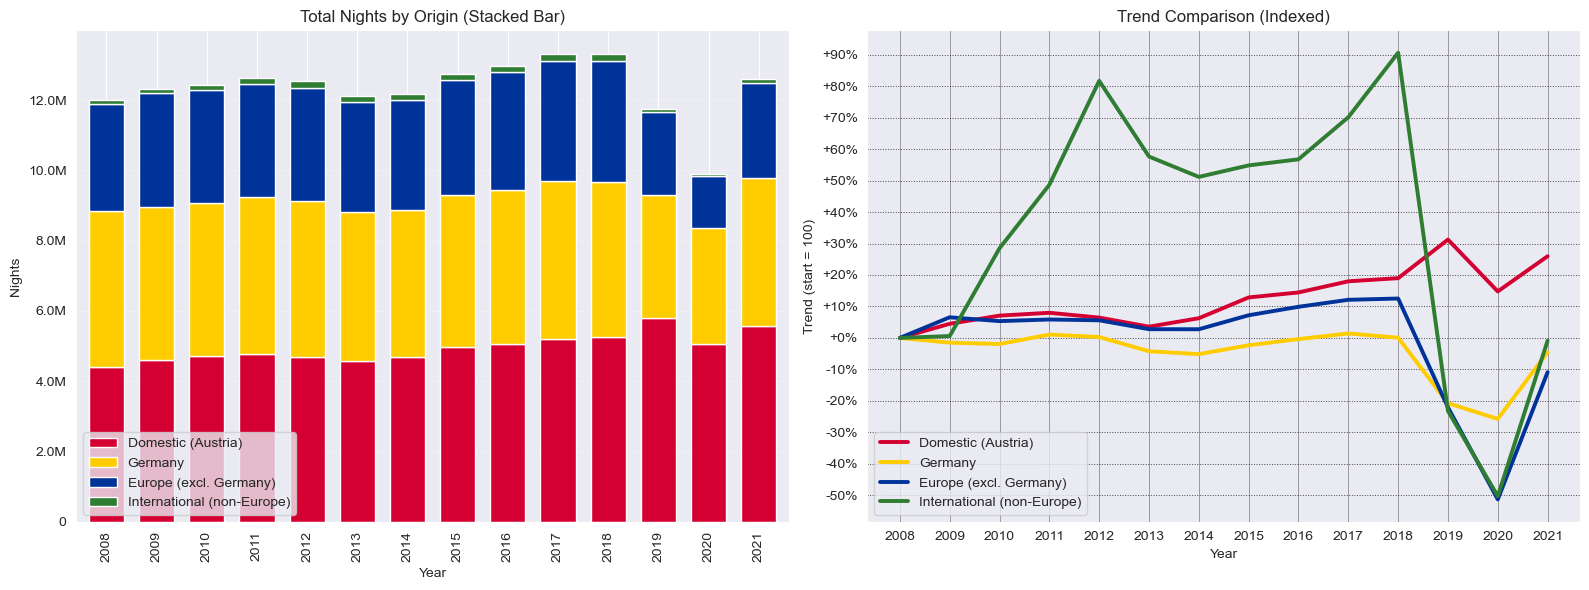

In [4]:

from matplotlib.ticker import MultipleLocator, FuncFormatter


group_b = df_tourism.groupby(['Tourismusjahr','Herkunft Kategorie']).agg({'Übernachtungen':'sum'}).reset_index()
pivot = group_b.pivot(index='Tourismusjahr', columns='Herkunft Kategorie', values='Übernachtungen').fillna(0)

# Map columns (origin categories)
pivot.columns = [cat_map.get(col, col) for col in pivot.columns]
categories = pivot.columns

years = pivot.index
values = [pivot[cat] for cat in categories]

fig, axs = plt.subplots(1,2,figsize=(16,6))

#Stacked bar chart with mapped labels

pivot.plot(kind='bar',
           stacked=True,
           ax=axs[0],
           legend=False,
           width=0.7,
           cmap=cmap,
           )

axs[0].set_xlabel('Year')
axs[0].set_ylabel('Nights')
axs[0].set_title('Total Nights by Origin (Stacked Bar)')
axs[0].get_yaxis().set_major_formatter(FuncFormatter(human_format))
axs[0].grid(axis='y', linestyle=':', alpha=0.7)
axs[0].legend(categories, loc='lower left')


i = 0
for cat in categories:
    cat_code = {v: k for k, v in cat_map.items()}.get(cat, cat)
    data = group_b[group_b['Herkunft Kategorie'] == cat_code].sort_values('Tourismusjahr')
    indexed = data['Übernachtungen'] / data['Übernachtungen'].iloc[0] * 100
    axs[1].plot(data['Tourismusjahr'], indexed, label=cat, color = color_map[cat])



# Thicken all lines drawn on axs[1]
for ln in axs[1].lines:
    ln.set_linewidth(2.8)
    ln.set_solid_capstyle('round')

# % delta formatter (100 -> 0%, 120 -> +20%)
def rel_fmt(y, _): return f"{(y/100 - 1)*100:+.0f}%"
axs[1].yaxis.set_major_formatter(FuncFormatter(rel_fmt))

# Grid + tick spacing
axs[1].xaxis.set_major_locator(MultipleLocator(1))    # yearly
axs[1].yaxis.set_major_locator(MultipleLocator(10))   # 10 index pts = 10%
axs[1].minorticks_on()
axs[1].grid(which='major', color='black', linestyle='-', linewidth=0.7, alpha=0.35)
axs[1].set_axisbelow(True)

axs[1].set_xlabel('Year')
axs[1].set_ylabel('Trend (start = 100)')
axs[1].set_title('Trend Comparison (Indexed)')
axs[1].grid(axis='y', linestyle=':', alpha=0.7)
axs[1].legend()

plt.tight_layout()
plt.show()



## 4. Accommodation Types and Tourist Origins

Show how many nights are spent in accommodations of different types. How does the
choice of accommodation depend on origin? (2 charts)

**Deliverables:**
- Bar chart: Nights per accommodation type.
- Grouped bar chart or heatmap: Origin vs. accommodation.

**Ask:**
- Do international tourists prefer hotels over private rentals?
- Are some types only popular among locals?

# Add a new totals column
# try vertical bar chart


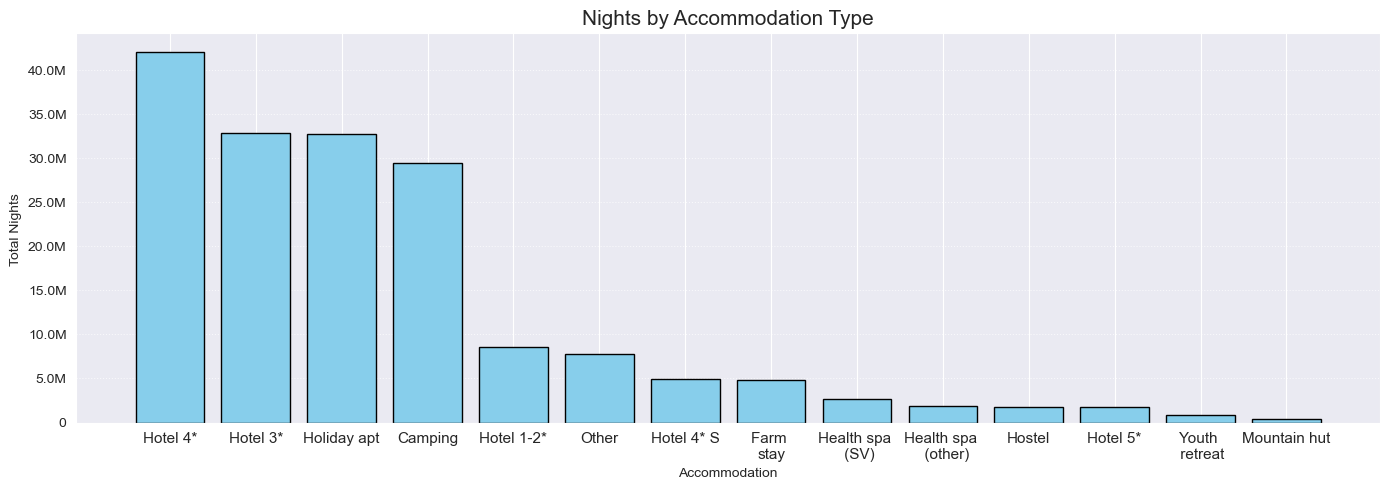

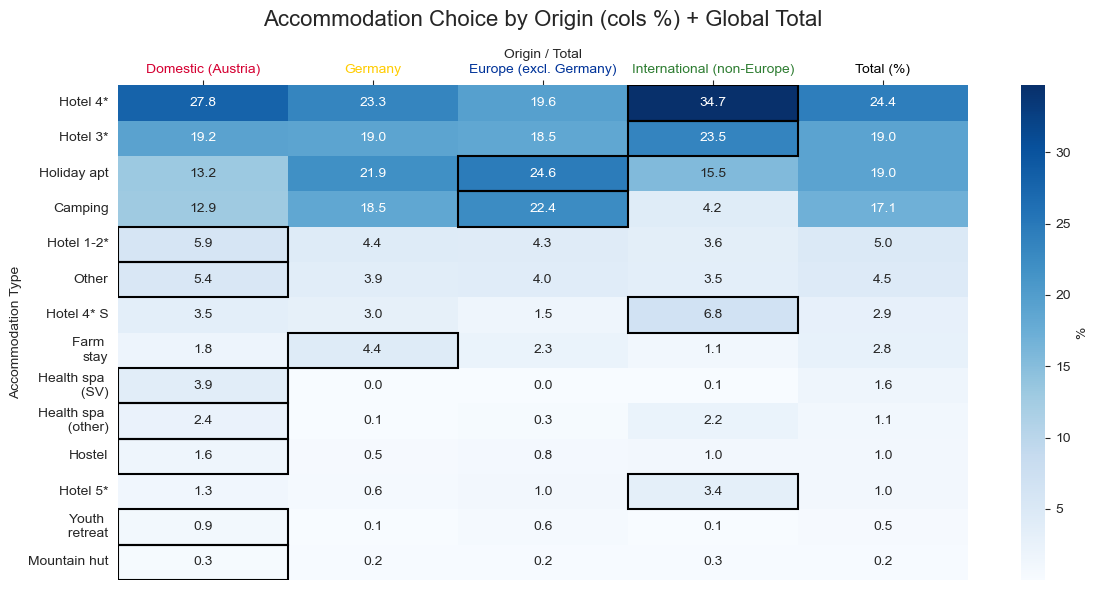

In [6]:
from matplotlib import patches
import seaborn  as sns
accom_map = {
    'Bewirtschaftete Schutzhütten': 'Mountain hut',
    'Campingplatz': 'Camping',
    'Ferienwohnung': 'Holiday apt',
    'Hotel 1 oder 2*': 'Hotel 1-2*',
    'Hotel 3*': 'Hotel 3*',
    'Hotel 4*': 'Hotel 4*',
    'Hotel 4* Superior': 'Hotel 4* S',
    'Hotel 5*': 'Hotel 5*',
    'Jugendherbergen u. -gästehäuser': 'Hostel',
    'Kinder- u. Jugenderholungsheime': 'Youth \n retreat',
    'Kurheim der Sozialversich.träger': 'Health spa \n (SV)',
    'Private u. öffentl. Kurheime': 'Health spa \n  (other)',
    'Sonstige Unterkunft': 'Other',
    'Unterkunft auf Bauernhof': 'Farm \nstay'
}


group_c = df_tourism.groupby(['Unterkunft']).agg({'Übernachtungen':'sum'})
group_c = group_c.reset_index()
group_c['Short'] = group_c['Unterkunft'].map(accom_map).fillna(group_c['Unterkunft'])
group_c =group_c.sort_values(by='Übernachtungen', ascending=False)
plt.figure(figsize=(14,5))
bars = plt.bar(group_c['Short'], group_c['Übernachtungen'], color='skyblue', edgecolor='black')
plt.title("Nights by Accommodation Type", fontsize=15)
plt.xlabel("Accommodation")
plt.ylabel("Total Nights ")
plt.gca().yaxis.set_major_formatter(FuncFormatter(human_format))
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.xticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()




group_b = df_tourism.groupby(['Unterkunft','Herkunft Kategorie']).agg({'Übernachtungen':'sum'})
group_b = group_b.reset_index()

pivot_b = group_b.pivot(index='Unterkunft', columns='Herkunft Kategorie', values='Übernachtungen').fillna(0)



pivot_raw = group_b.pivot(index='Unterkunft', columns='Herkunft Kategorie', values='Übernachtungen').fillna(0)
pivot_raw.columns = [cat_map.get(x, x) for x in pivot_raw.columns]
pivot_raw.index   = [accom_map.get(x, x) for x in pivot_raw.index]

pct = pivot_raw.div(pivot_raw.sum(axis=0), axis=1) * 100                    # column-normalized
pct['Total (%)'] = pivot_raw.sum(axis=1) / pivot_raw.values.sum() * 100     # global share
pivot_sorted = pct.sort_values('Total (%)', ascending=False)

plt.figure(figsize=(12,6))
ax = sns.heatmap(pivot_sorted, cmap='Blues', annot=True, fmt='.1f',
                 cbar_kws={'label': '%'})
ax.set_title('Accommodation Choice by Origin', fontsize=16, pad=16)
ax.set_xlabel('Origin / Total'); ax.set_ylabel('Accommodation Type')
ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()


for t in ax.get_xticklabels():
    t.set_color(color_map.get(t.get_text(), '#000000'))

# Highlight the max % in each column
for row_idx, row_name in enumerate(pivot_sorted.index):
    col_name_idmax = pivot_sorted.iloc[row_idx].idxmax()
    col_idx = list(pivot_sorted.columns).index(col_name_idmax)
    rect = patches.Rectangle(
        (col_idx, row_idx), 1, 1,
        linewidth=1.5, edgecolor='black', facecolor='none'
    )
    ax.add_patch(rect)


plt.tight_layout()
plt.show()

---

## 5. Estimated Stay Duration by Accommodation Type

The dataset is highly aggregated and only provides total arrivals (Ankünfte) and total spent
nights (Übernachtungen) in each category (year, accommodation, origin). Still, taking the
row-wise quotient of Übernachtungen by Ankünfte gives a rough estimate of the approx-
imate duration of stays. Show how this duration depends on the type of accommodation.
(1 chart)

**Formula:**
Estimated duration = `Übernachtungen / Ankünfte`

**Deliverable:**
- Box plot or bar chart: Average duration vs. accommodation type.

**Challenge:**
- Does duration vary significantly by accommodation?
- Which accommodations encourage longer stays?

---



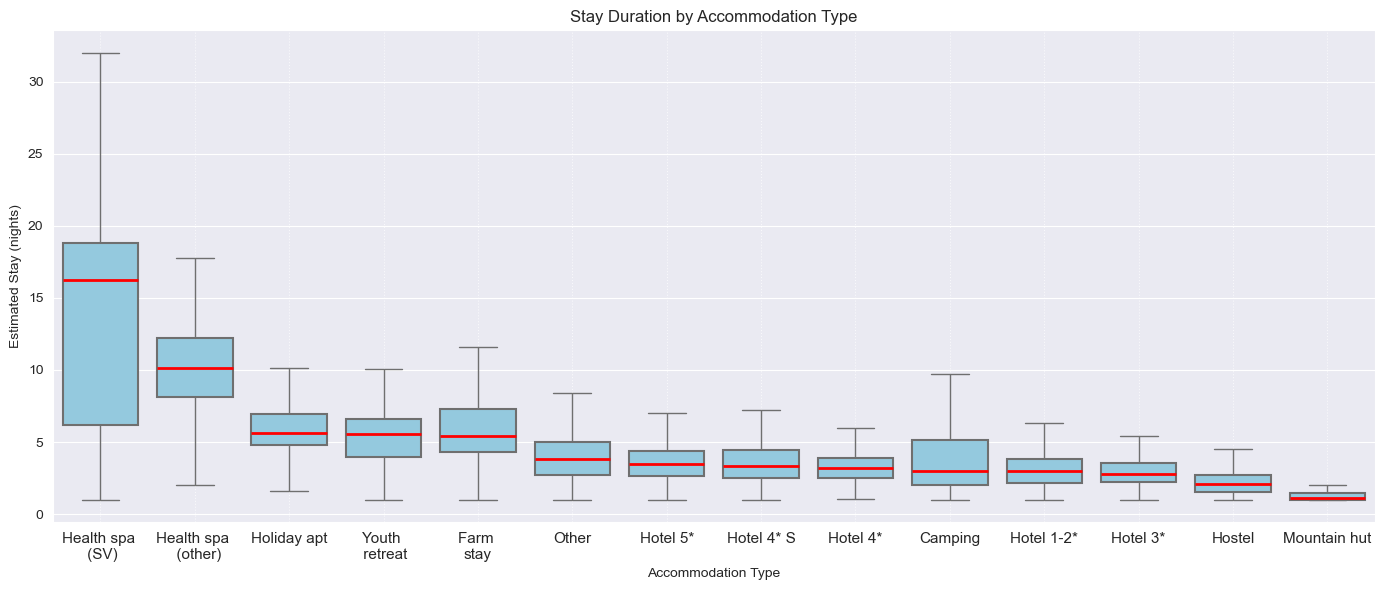

In [38]:

df_tourism['Dauer'] = df_tourism['Übernachtungen'] / df_tourism['Ankünfte']
df_tourism['Short'] = df_tourism['Unterkunft'].map(accom_map)

medians = df_tourism.groupby('Short')['Dauer'].median().sort_values(ascending=False)
ordered_accoms = medians.index.tolist()

plt.figure(figsize=(14,6))
sns.boxplot(
    y='Dauer',
    x='Short',
    data=df_tourism,
    order=ordered_accoms,
    showfliers=False,
    color='skyblue',
    boxprops=dict(linewidth=1.5),
    medianprops=dict(color='red', linewidth=2)
)
plt.ylabel('Estimated Stay (nights)')
plt.xlabel('Accommodation Type')
plt.title('Stay Duration by Accommodation Type')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.xticks( fontsize=11)

plt.tight_layout()
plt.show()
